# Incident prediction in time series using sliding window

The task is to predict whether an incident will occur within the next H steps (target window) based on the previous W steps (observation window). This is possible under the assumption that early signs of the incident are present in the observation window. This notebook uses the Future Context Modeling (FCM) technique, which predicts future context and then checks if it diverges from normal patterns.

More information about FCM:

 Zhao et al., [Abnormality Forecasting: Time Series Anomaly Prediction via Future Context Modeling](https://arxiv.org/abs/2410.12206), arXiv:2410.12206, 2024.

## Architecture
This notebook uses a GRU architecture to predict H steps from W observed steps (Forecaster). The Forecaster is trained first on clean data (without anomalies). An Autoencoder is then trained to reconstruct a combined window of W observed + H forecasted steps, using the frozen Forecaster, also on clean data. If the anomaly signs are present in the observed window, the predicted target window should amplify these signs, resulting in higher Autoencoder reconstruction error.

## Data
The notebook uses synthetic data. The base signal is a 1-dimensional composite of sine waves with added noise. Anomalies are generated by adding exponential value/noise spikes to the signal. The goal is to detect an anomaly before it reaches its peak.

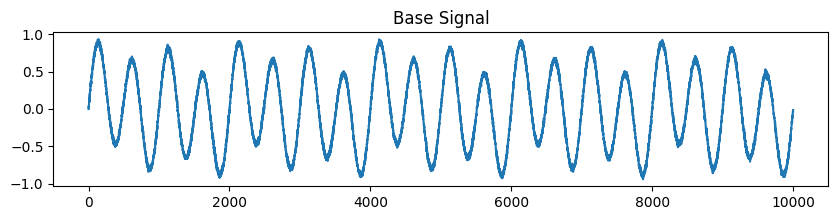

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# define observation window size, and target window size
W, H = 100, 100

def gen_base_signal(N = 10_000, noise = 0.02):
  # periods
  t1 = 2000
  t2 = 1000
  t3 = 500

  # aplitudes
  a1 = 0.1
  a2 = 0.2
  a3 = 0.7

  x1 = np.linspace(0, (N/t1)*2*np.pi, N)
  x2 = np.linspace(0, (N/t2)*2*np.pi, N)
  x3 = np.linspace(0, (N/t3)*2*np.pi, N)

  y = a1*np.sin(x1) + a2*np.sin(x2) + a3*np.sin(x3) + np.random.normal(0, noise, size=N)
  return y

plt.figure(figsize=(10, 2))
plt.title("Base Signal")
plt.plot(gen_base_signal())
plt.show()

### Train the forecaster

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class ForecasterGRU(nn.Module):
    def __init__(self, output_size):
        super().__init__()
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(64, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1]
        return self.fc(out)

def train_forecaster(model):
  base_sig = gen_base_signal()

  # create sliding windows
  X_train = np.array([base_sig[i:i+W] for i in range(len(base_sig)-W-H)])
  Y_train = np.array([base_sig[i+W:i+W+H] for i in range(len(base_sig)-W-H)])

  X_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
  Y_t = torch.tensor(Y_train, dtype=torch.float32)

  dataset = TensorDataset(X_t, Y_t)
  dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  loss_fn = nn.MSELoss()

  for epoch in range(10):
      epoch_loss = 0
      for x, y in dataloader:
          optimizer.zero_grad()
          y_pred = model(x)
          loss = loss_fn(y_pred, y)
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()

      print(f"Epoch {epoch+1} loss: {epoch_loss/len(dataloader):.6f}")
      if epoch_loss/len(dataloader) < 0.001:
        break

forecaster_model = ForecasterGRU(H)
train_forecaster(forecaster_model)

Epoch 1 loss: 0.118333
Epoch 2 loss: 0.007123
Epoch 3 loss: 0.004262
Epoch 4 loss: 0.003311
Epoch 5 loss: 0.003157
Epoch 6 loss: 0.002819
Epoch 7 loss: 0.002538
Epoch 8 loss: 0.002361
Epoch 9 loss: 0.002012
Epoch 10 loss: 0.001912


### Evaluate the forecaster

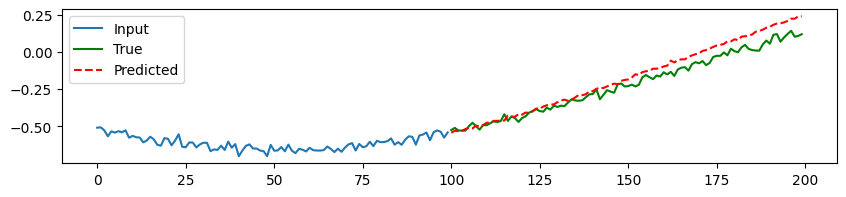

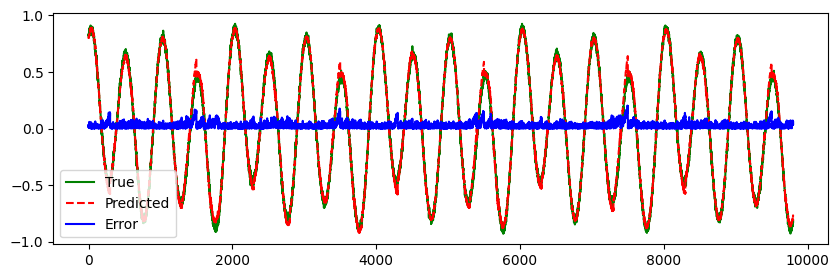

In [3]:
def eval_forecaster(model):
  sig_test = gen_base_signal()

  # close up
  i = len(sig_test)//3
  x_0 = sig_test[i:i+W]
  y_true = sig_test[i+W:i+W+H]

  model.eval()
  with torch.no_grad():
      x_t = torch.tensor(x_0, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
      y_pred = model(x_t).squeeze().numpy()

  plt.figure(figsize=(10, 2))
  plt.plot(range(W), x_0, label='Input')
  plt.plot(range(W, W+H), y_true, label='True', color='green')
  plt.plot(range(W, W+H), y_pred, label='Predicted', color='red', linestyle='--')
  plt.legend()
  plt.show()

  # full signal
  pred_sig, true_sig, error = [], [], []

  with torch.no_grad():
      for i in range(0, len(sig_test)-W-H, H):
          x = sig_test[i:i+W]
          y = sig_test[i+W:i+W+H]

          x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
          y_pred = model(x_t).squeeze().numpy()

          pred_sig.append(y_pred)
          true_sig.append(y)
          error.append(np.abs(y-y_pred))

  pred_sig = np.concatenate(pred_sig)
  true_sig = np.concatenate(true_sig)
  error = np.concatenate(error)

  plt.figure(figsize=(10, 3))
  plt.plot(true_sig, label='True', color='green')
  plt.plot(pred_sig, label='Predicted', color='red', linestyle='--')
  plt.plot(error, label='Error', color='blue')
  plt.legend()
  plt.show()

eval_forecaster(forecaster_model)



## Train the Autoencoder

In [4]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, latent_size=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_size)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

def train_ae(model_ae, model_forecaster):
  sig_base = gen_base_signal()

  model_forecaster.eval()

  # create training data from combining real steps with forecasted steps
  X_train = []
  with torch.no_grad():
    for i in range(len(sig_base)-W-H):
      x = sig_base[i:i+W]
      x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
      y_pred = model_forecaster(x_t).squeeze().numpy()

      X_train.append(np.concatenate((x, y_pred)))

  X_train = np.array(X_train)
  X_t = torch.tensor(X_train, dtype=torch.float32)

  dataset = TensorDataset(X_t)
  dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

  optimizer = torch.optim.Adam(model_ae.parameters(), lr=1e-3)
  criterion = nn.MSELoss()

  for epoch in range(10):
      epoch_loss = 0
      for (x,) in dataloader:
          optimizer.zero_grad()
          x_pred = model_ae(x)
          loss = criterion(x_pred, x)
          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()

      print(f"Epoch {epoch+1} loss: {epoch_loss/len(dataloader):.6f}")
      if epoch_loss/len(dataloader) < 0.001:
        break

model_ae = AutoEncoder(W+H)

train_ae(model_ae, forecaster_model)

Epoch 1 loss: 0.033667
Epoch 2 loss: 0.001054
Epoch 3 loss: 0.000805


## Combine models

In [5]:
import copy

class CombinedPredictor:
  def __init__(self, forecaster, ae):
    self.forecaster = copy.deepcopy(forecaster)
    self.ae = copy.deepcopy(ae)
    self.forecaster.eval()
    self.ae.eval()

  def predict_with_info(self, x):
    with torch.no_grad():
      x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
      x_forecast = self.forecaster(x_t).squeeze().numpy()
      x_comb = np.concatenate((x, x_forecast))
      x_rec = self.ae(torch.tensor(x_comb, dtype=torch.float32)).squeeze().numpy()
      error = np.mean(np.abs(x_comb - x_rec))
      return x_forecast, x_rec, error

  def predict(self, x):
    _,_,error = self.predict_with_info(x)
    return error

combined_predictor = CombinedPredictor(forecaster_model, model_ae)

## Evaluate combined models

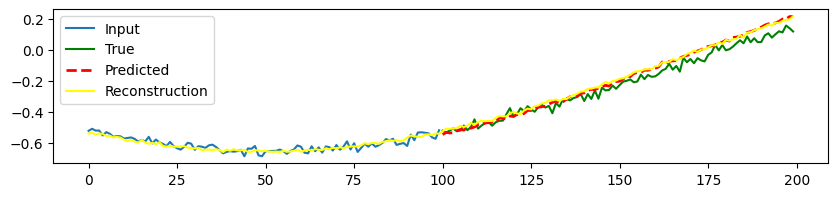

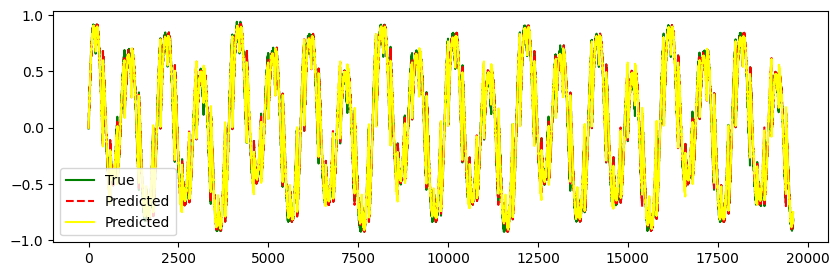

In [6]:
def eval_combined(combined_predictor):
  sig_test = gen_base_signal()

  # closeup
  i = len(sig_test)//3
  x_0 = sig_test[i:i+W]
  forecast_true = sig_test[i+W:i+W+H]

  x_forecast, x_rec, error = combined_predictor.predict_with_info(x_0)

  plt.figure(figsize=(10, 2))
  plt.plot(range(W), x_0, label='Input')
  plt.plot(range(W, W+H), forecast_true, label='True', color='green')
  plt.plot(range(W, W+H), x_forecast, label='Predicted', color='red', linestyle='--', linewidth=2)
  plt.plot(range(W+H), x_rec, label='Reconstruction', color='yellow', linestyle='-')
  plt.legend()
  plt.show()

  # full signal
  pred_sig, true_sig, rec_sig = [], [], []

  for i in range(0, len(sig_test)-W-H, H):
      x = sig_test[i:i+W]
      y = sig_test[i+W:i+W+H]

      y_pred, x_rec, error = combined_predictor.predict_with_info(x)

      pred_sig.append(x)
      pred_sig.append(y_pred)
      true_sig.append(x)
      true_sig.append(y)
      rec_sig.append(x_rec)

  pred_sig = np.concatenate(pred_sig)
  true_sig = np.concatenate(true_sig)
  rec_sig = np.concatenate(rec_sig)

  plt.figure(figsize=(10, 3))
  plt.plot(true_sig, label='True', color='green')
  plt.plot(pred_sig, label='Predicted', color='red', linestyle='--')
  plt.plot(rec_sig, label='Predicted', color='yellow', linestyle='-')
  plt.legend()
  plt.show()

eval_combined(combined_predictor)

## Generate testing scenarios
Test scenarios are generated by sampling random windows from the base signal, either leaving them unchanged (class 0, no incident) or adding a spike in value/noise (class 1, incident). Spikes are positioned so they begin in the observation window and peak in the target window, ensuring they are possible to detect early. Classes are balanced.

Anomaly type: Exp_value_change_early


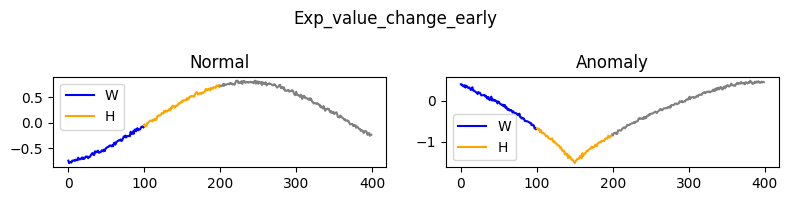

Anomaly type: Exp_value_change_late


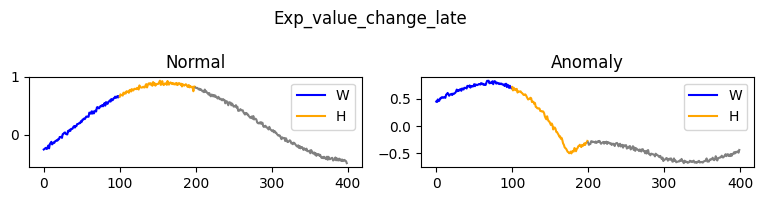

Anomaly type: Exp_noise_change


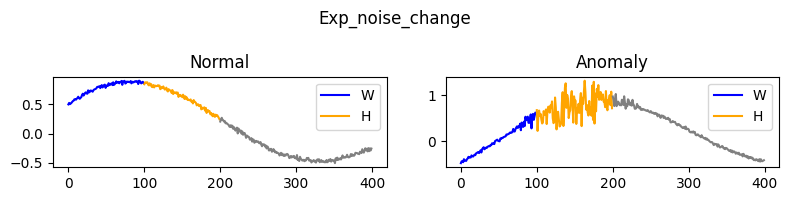

In [7]:
def gen_test_data():
  N = 250

  base_sig = gen_base_signal()

  window_size = W+H+200

  def gen_exp_spike(steepness = 2, duration = 200):
    return (np.concatenate([np.power(np.e, np.linspace(0, steepness, duration//2)),
                            np.power(np.e, np.linspace(steepness, 0, duration//2))]) - 1.0) / np.power(np.e, steepness)

  def gen_test_cases(anomalies, anomaly_pos):
    # clear windows
    X = []
    for _ in range(N*2):
      window_pos = np.random.randint(0, len(base_sig)-window_size)
      window = base_sig[window_pos:window_pos+window_size]
      X.append(window)

    X = np.array(X)

    # add anomalies
    anomaly_ids = np.random.permutation(len(X))[:len(anomalies)]
    Y = np.zeros(len(X))

    for i in range(0, len(anomaly_ids)):
      anomaly_sig = anomalies[i]
      X[anomaly_ids[i], anomaly_pos:anomaly_pos+len(anomaly_sig)] += anomaly_sig

    Y[anomaly_ids] = 1

    return X,Y


  test_data = dict()

  # exponantial value changes
  val_anomalies = np.array([np.random.choice([1.0, -1.0]) * gen_exp_spike(duration = 200) for _ in range(N)])
  X,Y = gen_test_cases(val_anomalies, int(W*0.5))
  test_data["Exp_value_change_early"] = (X,Y)

  val_anomalies = np.array([np.random.choice([1.0, -1.0]) * gen_exp_spike(duration = 200) for _ in range(N)])
  X,Y = gen_test_cases(val_anomalies, int(W*0.75))
  test_data["Exp_value_change_late"] = (X,Y)

  # exponantial noise changes
  noise_anomalies = np.array([gen_exp_spike(duration=200) * np.random.normal(0, 0.5, size=200) for _ in range(N)])
  X,Y = gen_test_cases(noise_anomalies, int(W*0.5))
  test_data["Exp_noise_change"] = (X,Y)

  return test_data

def plot_test_data(test_data):
  for label, (X, Y) in test_data.items():
    print(f"Anomaly type: {label}")

    normal_idx = np.argmax(Y == 0)
    anomaly_idx = np.argmax(Y == 1)

    fig, axes = plt.subplots(1, 2, figsize=(8, 2))
    for ax, idx, title in zip(axes, [normal_idx, anomaly_idx], ["Normal", "Anomaly"]):
        ax.plot(range(W), X[idx][:W], color='blue', label='W')
        ax.plot(range(W, W+H), X[idx][W:W+H], color='orange', label='H')
        ax.plot(range(W+H,len(X[idx])), X[idx][W+H:], color='gray')
        ax.legend()
        ax.set_title(title)

    plt.suptitle(label)
    plt.tight_layout()
    plt.show()


test_data = gen_test_data()
plot_test_data(test_data)

## Run tests

Anomaly type: Exp_value_change_early
              precision    recall  f1-score   support

           0       1.00      0.88      0.93       250
           1       0.89      1.00      0.94       250

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



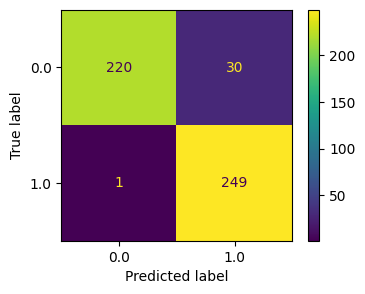

Anomaly type: Exp_value_change_late
              precision    recall  f1-score   support

           0       0.63      0.84      0.72       250
           1       0.76      0.51      0.61       250

    accuracy                           0.67       500
   macro avg       0.69      0.67      0.66       500
weighted avg       0.69      0.67      0.66       500



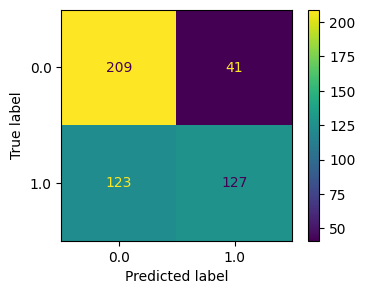

Anomaly type: Exp_noise_change
              precision    recall  f1-score   support

           0       0.57      0.87      0.69       250
           1       0.72      0.34      0.47       250

    accuracy                           0.61       500
   macro avg       0.65      0.61      0.58       500
weighted avg       0.65      0.61      0.58       500



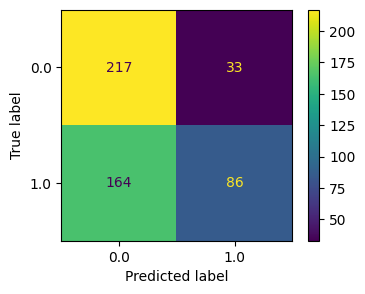

In [8]:
def run_tests(combined_predictor):
  from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

  for label, (X,Y) in test_data.items():
    errors = np.array([combined_predictor.predict(x[:W]) for x in X])
    threshold = 0.025
    preds = (errors > threshold).astype(int)
    print(f"Anomaly type: {label}")
    print('='*20)
    print(classification_report(Y.astype(int), preds))
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(Y, preds, ax=ax)
    plt.show()
    print('='*20)

run_tests(combined_predictor)

## Summary
The combined predictor performed well on early value anomalies, achieving high recall and low false positive rate. It performed significantly worse on the late value anomalies, with lower recall. This could potentially be improved by making the forecasting model more sensitive.

The model performed poorly on noise spikes. This is because the GRU forecaster was trained with MSE loss, which is based on the mean and is insensitive to variance changes. One way to adress this would be to feed in rolling standard deviation in a separate channel. Another would be to use a Forecaster capable of modeling variance.